In [1]:
from sqlalchemy import create_engine, text
import sqlalchemy
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- myntra_sales_dataset


In [3]:
for table in tables:
       print(f"\n Table: {table}")
    #    query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(text(f"SELECT COUNT(*) FROM {table}"), engine)
       print(f"{table}", df.iloc[0,0])
       df = pd.read_sql(f"SELECT * FROM {table}", engine)
       display(df)


 Table: clean_dataset
clean_dataset 8000


,order_id,order_date,order_month,order_quarter,order_year,customer_id,gender,age,city,state,...,mrp,discount_percent,selling_price,quantity,total_amount,payment_mode,order_channel,order_status,delivery_days,rating
0,MYN100001,2023-03-03,March,Q1,2023,CUST00139,Female,27,Delhi,Delhi,...,5729.0,50,2864.5,1,2864.5,UPI,Website,Delivered,3,5.0
1,MYN100002,2024-03-13,March,Q1,2024,CUST00298,Female,40,Guwahati,Assam,...,2129.0,0,2129.0,1,2129.0,Debit Card,Mobile App,Delivered,9,5.0
2,MYN100003,2025-05-13,May,Q2,2025,CUST01162,Female,39,Kolkata,West Bengal,...,5699.0,10,5129.1,1,5129.1,Credit Card,Mobile App,Delivered,8,3.0
3,MYN100004,2023-02-13,February,Q1,2023,CUST02043,Male,48,Jaipur,Rajasthan,...,2169.0,30,1518.3,1,1518.3,UPI,Mobile App,Cancelled,6,4.0
4,MYN100005,2023-07-14,July,Q3,2023,CUST00020,Male,52,Surat,Gujarat,...,1729.0,0,1729.0,1,1729.0,Cash on Delivery,Website,Delivered,8,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,MYN107996,2025-09-28,September,Q3,2025,CUST01946,Female,52,Lucknow,Uttar Pradesh,...,929.0,20,743.2,2,1486.4,UPI,Mobile App,Delivered,5,4.0
7996,MYN107997,2024-10-19,October,Q4,2024,CUST00377,Female,26,Pune,Maharashtra,...,1189.0,10,1070.1,2,2140.2,Cash on Delivery,Mobile App,Delivered,2,5.0
7997,MYN107998,2025-01-20,January,Q1,2025,CUST01432,Male,55,Jaipur,Rajasthan,...,1019.0,20,815.2,2,1630.4,Cash on Delivery,Mobile Web,Delivered,9,4.0
7998,MYN107999,2025-06-03,June,Q2,2025,CUST01225,Male,51,Patna,Bihar,...,1369.0,40,821.4,1,821.4,Debit Card,Website,Returned,4,4.0



 Table: myntra_sales_dataset
myntra_sales_dataset 8000


,Order_ID,Order_Date,Order_Month,Order_Quarter,Order_Year,Customer_ID,Customer_Name,Gender,Age,City,...,MRP,Discount_Percent,Selling_Price,Quantity,Total_Amount,Payment_Mode,Order_Channel,Order_Status,Delivery_Days,Rating
0,MYN100001,2023-03-03,March,Q1,2023,CUST00139,Vaishnavi Sathe,Female,27,Delhi,...,5729.0,50,2864.5,1,2864.5,UPI,Website,Delivered,3,5.0
1,MYN100002,2024-03-13,March,Q1,2024,CUST00298,Geetika Mistry,Female,40,Guwahati,...,2129.0,0,2129.0,1,2129.0,Debit Card,Mobile App,Delivered,9,5.0
2,MYN100003,2025-05-13,May,Q2,2025,CUST01162,Arunima Chokshi,Female,39,Kolkata,...,5699.0,10,5129.1,1,5129.1,Credit Card,Mobile App,Delivered,8,3.0
3,MYN100004,2023-02-13,February,Q1,2023,CUST02043,Hemang Mitter,Male,48,Jaipur,...,2169.0,30,1518.3,1,1518.3,UPI,Mobile App,Cancelled,6,NaN
4,MYN100005,2023-07-14,July,Q3,2023,CUST00020,Peter Kadakia,Male,52,Surat,...,1729.0,0,1729.0,1,1729.0,Cash on Delivery,Website,Delivered,8,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,MYN107996,2025-09-28,September,Q3,2025,CUST01946,Januja Borah,Female,52,Lucknow,...,929.0,20,743.2,2,1486.4,UPI,Mobile App,Delivered,5,4.0
7996,MYN107997,2024-10-19,October,Q4,2024,CUST00377,Chaman Chander,Female,26,Pune,...,1189.0,10,1070.1,2,2140.2,Cash on Delivery,Mobile App,Delivered,2,5.0
7997,MYN107998,2025-01-20,January,Q1,2025,CUST01432,Indrajit Dave,Male,55,Jaipur,...,1019.0,20,815.2,2,1630.4,Cash on Delivery,Mobile Web,Delivered,9,4.0
7998,MYN107999,2025-06-03,June,Q2,2025,CUST01225,Veer Halder,Male,51,Patna,...,1369.0,40,821.4,1,821.4,Debit Card,Website,Returned,4,NaN


In [4]:
df = pd.read_sql_query(text("SELECT * FROM clean_dataset"), engine)

In [76]:
df.describe()

,order_year,age,mrp,discount_percent,selling_price,quantity,total_amount,delivery_days,rating
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2023.98975,35.115500,2953.098750,27.158750,2149.072088,1.240625,2658.072238,5.500500,3.910750
std,0.81898,11.308654,1771.650285,17.907537,1425.416428,0.529632,2201.736248,2.299872,0.994941
min,2023.00000,16.000000,159.000000,0.000000,67.600000,1.000000,67.600000,2.000000,1.000000
25%,2023.00000,25.000000,1459.000000,10.000000,990.775000,1.000000,1103.350000,3.000000,4.000000
50%,2024.00000,35.000000,2689.000000,30.000000,1871.200000,1.000000,2135.200000,5.000000,4.000000
75%,2025.00000,45.000000,4379.000000,40.000000,3079.375000,1.000000,3597.300000,8.000000,5.000000
max,2025.00000,55.000000,7999.000000,60.000000,7699.000000,3.000000,21300.300000,9.000000,5.000000


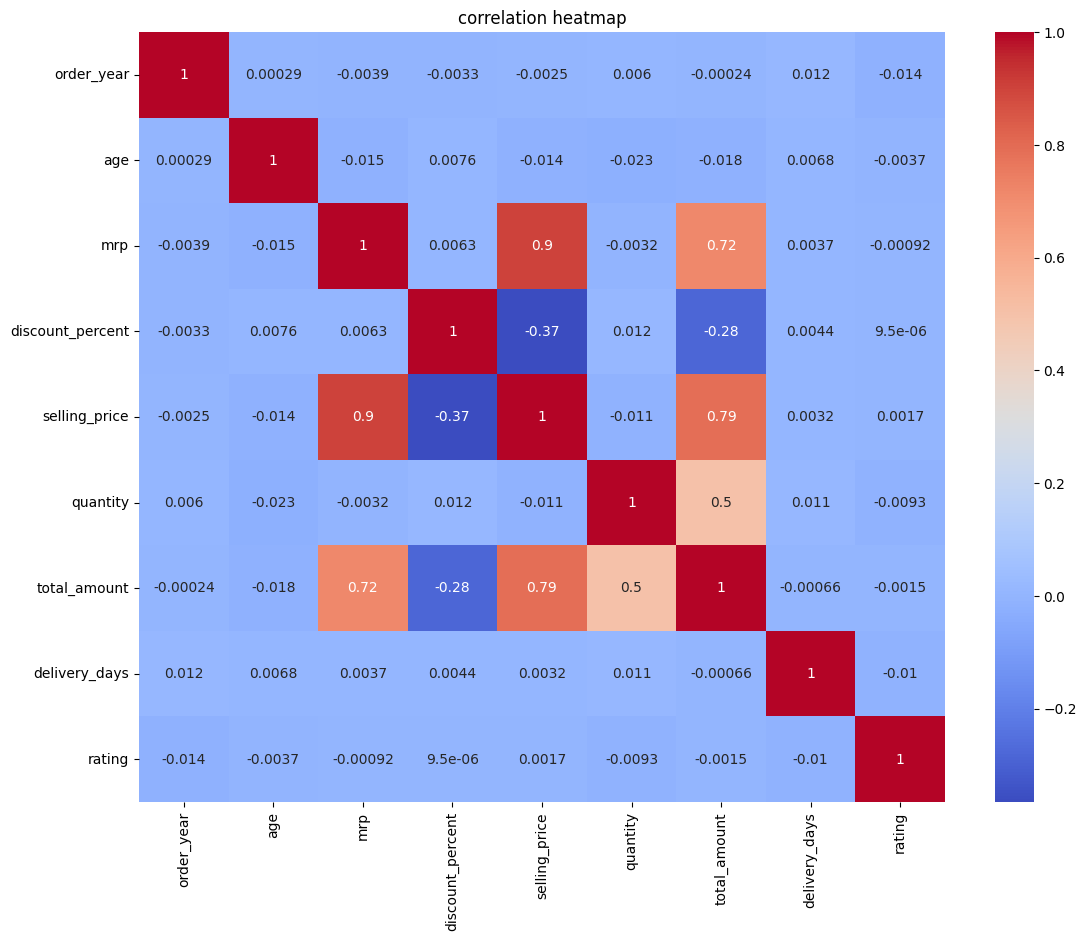

In [77]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

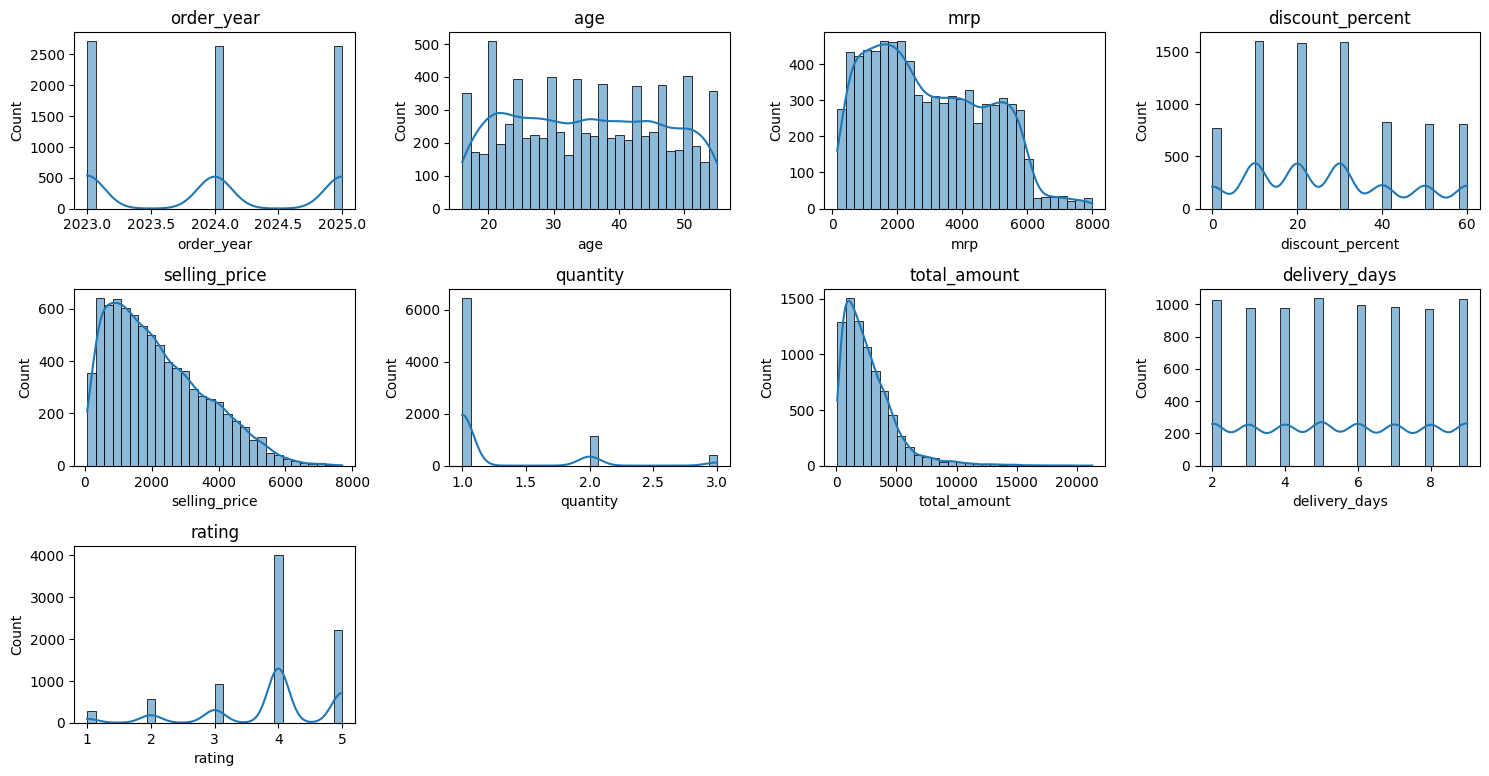

In [78]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

* sql analysis

1 . Which product categories generate the highest total revenue and average order value? 

In [79]:
highest_renue = pd.read_sql_query(text("""select category , sum(total_amount) as total_revenue ,  round(sum(total_amount) / count(order_id),2) as AOV from clean_dataset group by category order by total_revenue desc , AOV desc """),engine)
display(highest_renue)

,category,total_revenue,AOV
0,Women,7098996.4,2889.29
1,Men,6690071.5,3021.71
2,Kids,3345980.8,3025.30
3,Footwear,1809408.3,2853.96
4,Beauty,1328603.9,1190.51
5,Home & Living,991517.0,2096.23


2 . Which top 10 brands contribute the largest share of total revenue?

In [80]:
brand_revenue = pd.read_sql_query(text("""select brand ,round(sum(total_amount),2) as total_revenue , 
round(100.0 * sum(total_amount) / sum(sum(total_amount)) over(),2) as pct_of_total_revenue 
from clean_dataset group by brand order by  pct_of_total_revenue desc limit 10"""),engine)
display(brand_revenue)

,brand,total_revenue,pct_of_total_revenue
0,H&M,1720104.1,8.09
1,Roadster,1664711.6,7.83
2,Puma,1189064.9,5.59
3,AND,956734.1,4.50
4,W,934285.5,4.39
5,Levis,911664.2,4.29
6,Vero Moda,902183.5,4.24
7,Only,885732.6,4.17
8,Biba,885791.0,4.17
9,Zara,864596.0,4.07


3 . How does average order value and total revenue differ across Insider, Insider Gold, and Non-Member customers?

,membership_tier,total_revenue,AOV
0,Insider,9711831.7,2635.50
1,Non-Member,8522002.3,2684.10
2,Insider Gold,3030743.9,2658.55


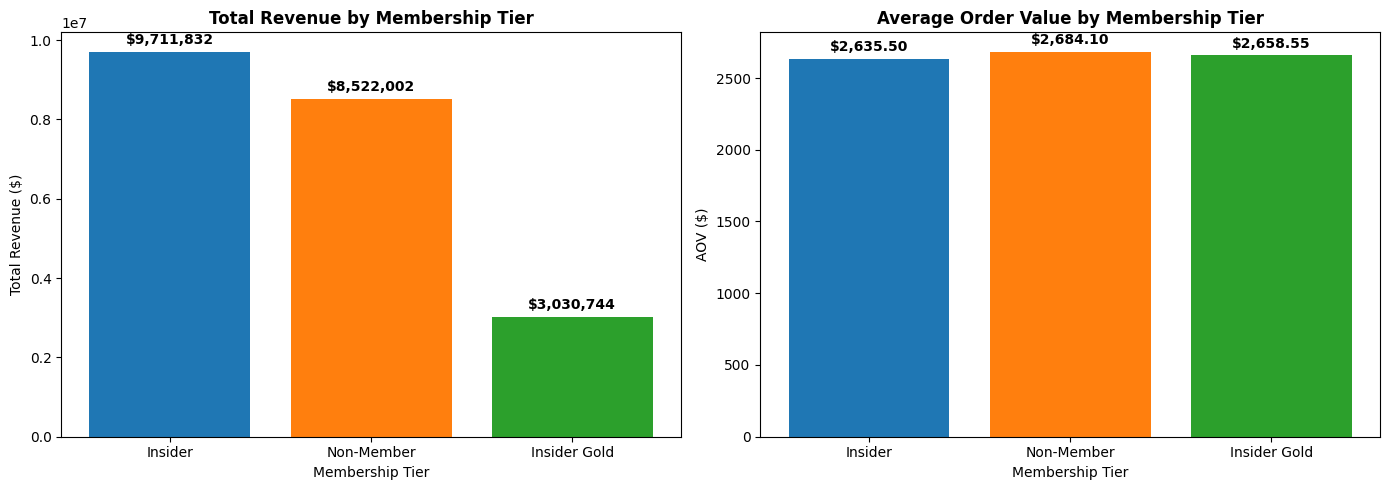

In [81]:
membership_tier = pd.read_sql_query(text("""select membership_tier , sum(total_amount) as total_revenue ,  round(sum(total_amount) / count(order_id),2) as AOV from clean_dataset group by membership_tier order by total_revenue desc , AOV desc """),engine)
display(membership_tier)

# Create a visualization comparing membership tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Revenue by Membership Tier
axes[0].bar(membership_tier['membership_tier'], membership_tier['total_revenue'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Total Revenue by Membership Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_xlabel('Membership Tier')
for i, v in enumerate(membership_tier['total_revenue']):
    axes[0].text(i, v + 200000, f'${v:,.0f}', ha='center', fontweight='bold')

# Plot 2: Average Order Value by Membership Tier
axes[1].bar(membership_tier['membership_tier'], membership_tier['AOV'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Average Order Value by Membership Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AOV ($)')
axes[1].set_xlabel('Membership Tier')
for i, v in enumerate(membership_tier['AOV']):
    axes[1].text(i, v + 50, f'${v:,.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

4 . Which payment modes are associated with higher average order values?

In [82]:
payment_mode = pd.read_sql_query(text("""select payment_mode , round(sum(total_amount) / count(order_id),2) as AOV from clean_dataset group by payment_mode order by AOV desc """),engine)
display(payment_mode)

,payment_mode,AOV
0,Net Banking,2762.03
1,Cash on Delivery,2685.63
2,Credit Card,2676.64
3,Debit Card,2669.23
4,UPI,2638.17
5,Myntra Wallet,2510.19


5 . Which order channel (Website, Mobile App, Mobile Web) drives the most revenue and highest average order value?

In [83]:
order_chennal = pd.read_sql_query(text("""select order_channel , sum(total_amount) as total_revenue ,  round(sum(total_amount) / count(order_id),2) as AOV from clean_dataset group by order_channel order by total_revenue desc , AOV desc """),engine)
display(order_chennal)

,order_channel,total_revenue,AOV
0,Mobile App,13257265.9,2667.46
1,Website,4743629.3,2669.46
2,Mobile Web,3263682.7,2604.69


6 . Which states/cities contribute the most revenue, and how concentrated is revenue in the top 5? 

In [84]:
state_city_revenue =pd.read_sql_query(text("""select state , city , sum(total_amount) as total_revenue from clean_dataset group by state , city order by total_revenue desc"""),engine)
print("=== Top 10 State-City by Revenue (Delivered only) ===")
display(state_city_revenue) 

overall_revenue = state_city_revenue['total_revenue'].sum()
print("=== overall revenue ===")
display(overall_revenue)

top5_revenue = state_city_revenue.head(5)['total_revenue'].sum()
print("=== top5 reveue ===")
display(top5_revenue)

top5_share = (top5_revenue / overall_revenue) * 100
print("=== Top 5 revenue share ===")
display(top5_share.round(2))

=== Top 10 State-City by Revenue (Delivered only) ===


,state,city,total_revenue
0,Bihar,Patna,1359261.9
1,Kerala,Kochi,1308576.7
2,Chandigarh,Chandigarh,1258844.0
3,Uttar Pradesh,Lucknow,1192684.1
4,Tamil Nadu,Chennai,1073619.6
5,Assam,Guwahati,1072311.0
6,Maharashtra,Pune,1063116.4
7,Maharashtra,Mumbai,1055281.1
8,West Bengal,Kolkata,1050627.0
9,Tamil Nadu,Coimbatore,1046378.0


=== overall revenue ===


np.float64(21264577.899999984)

=== top5 reveue ===


np.float64(6192986.299999997)

=== Top 5 revenue share ===


np.float64(29.12)

7 . Discount effectiveness — Using discount bands (0–10%, 11–25%, 26–40%, 41%+), does higher discount actually correlate with higher quantity sold and revenue(Objective: tests whether the discounting strategy is working.)

In [85]:
def discount_band(val):
    if 0 <= val <= 10:
        return "0-10% (Low)"
    elif 11 <= val <= 25:
        return "11-25% (Medium)"
    elif 26 <= val <= 40:
        return "26-40% (High)"
    else:
        return "41%+ (Very High)"

df['discount_percent_cat'] = df['discount_percent'].apply(discount_band)

discount_qty = df.groupby('discount_percent_cat').agg(
    orders = ('order_id' , 'count'),
    high_qty = ('quantity' , 'max'),
    avg_qty = ('quantity' , 'mean'),
    total_qty = ('quantity' , 'sum'),
    total_revenue = ('total_amount' , 'sum')
).round(2)
display(discount_qty)

,orders,high_qty,avg_qty,total_qty,total_revenue
discount_percent_cat,,,,,
0-10% (Low),2382,3,1.24,2946,8003754.2
11-25% (Medium),1588,3,1.25,1978,4656089.6
26-40% (High),2418,3,1.24,2988,5872581.3
41%+ (Very High),1612,3,1.25,2013,2732152.8


**Quantity: Average quantity per order is almost flat (~1.24–1.25) across all discount bands. Higher discounts do not drive higher units sold per transaction.**

**Total revenue is highest in the Low and High bands mainly because those bands have more orders, not because the discount itself is more effective.**

8 . Underperformers despite discount — Which products have high discount percentages but still show low quantity sold? (Objective: flags dead stock that discounting isn't clearing.)

In [86]:
underperformance = pd.read_sql_query(text("""with a as (select product_name , round(avg(discount_percent),2) as high_avg_discount , 
sum(quantity) as low_qty , count(*) as total_orders
from clean_dataset group by product_name),
b as (select * , ntile(4) over(order by high_avg_discount desc) as high_avg_discount_group , 
ntile(4) over(order by low_qty asc) as low_avg_qty_group from a )
select product_name , high_avg_discount , low_qty , total_orders from b where high_avg_discount_group = 1 
and low_avg_qty_group = 1 order by high_avg_discount desc , low_qty asc limit 10; """),engine)
display(underperformance)

,product_name,high_avg_discount,low_qty,total_orders
0,Levis Casual Cap,60.0,1.0,1
1,Vero Moda Striped Cap,60.0,1.0,1
2,HRX Kids Slim Fit Trousers,60.0,1.0,1
3,Puma Embroidered Kurta Set,60.0,1.0,1
4,Gini and Jony Oversized T-Shirt,60.0,1.0,1
5,L'Oreal Graphic Sunscreen,60.0,1.0,1
6,Bombay Dyeing Graphic Wall Art,60.0,1.0,1
7,Portico Slim Fit Cookware Set,60.0,1.0,1
8,Puma Relaxed Fit Jeans,60.0,1.0,1
9,US Polo Assn Floral Flip Flops,60.0,1.0,1


9 . Rating vs sales mismatch — Which products have high order volume but rating below 3, filtered to Delivered orders only? (Objective: surfaces quality issues on popular items before they hurt brand trust.)

In [87]:
rating_sale = pd.read_sql_query(text("""select product_name , brand , category , count(order_id) as total_orders , round(avg(rating),2) as avg_rate
from clean_dataset where rating < 3 and order_status = "Delivered"
group by product_name , brand , category order by total_orders desc;"""),engine)
display(rating_sale)

,product_name,brand,category,total_orders,avg_rate
0,Nykaa Checked Body Mist,Nykaa,Beauty,4,1.75
1,Roadster Slim Fit Cardigan,Roadster,Women,2,2.00
2,US Polo Kids Slim Fit Shorts,US Polo Kids,Kids,2,2.00
3,Portico Embroidered Cushion Cover Set,Portico,Home & Living,2,2.00
4,Story@Home Checked Storage Container Set,Story@Home,Home & Living,2,1.50
...,...,...,...,...,...
812,Biba Oversized Cap,Biba,Women,1,2.00
813,Vero Moda Printed Saree,Vero Moda,Women,1,2.00
814,Spaces Oversized Storage Container Set,Spaces,Home & Living,1,1.00
815,AND Solid Sneakers,AND,Women,1,2.00


10 . Delivery time by category — Which categories/sub-categories have the highest average delivery days? (Objective: identifies fulfillment bottlenecks by product type.)

In [88]:
category_delivery = pd.read_sql_query(text("""select category  , sub_category , round(avg(delivery_days),2) as avg_delivery_days from clean_dataset group by category , sub_category order by avg_delivery_days desc """),engine)
display(category_delivery)

,category,sub_category,avg_delivery_days
0,Home & Living,Furnishing,5.84
1,Kids,Footwear,5.75
2,Beauty,Haircare,5.74
3,Men,Bottomwear,5.69
4,Footwear,Flip Flops,5.67
5,Men,Winterwear,5.65
6,Beauty,Skincare,5.62
7,Footwear,Sandals,5.60
8,Kids,Bottomwear,5.59
9,Kids,Innerwear,5.58


11 . Return & cancellation rate by category/brand — What % of orders are Returned or Cancelled, broken down by category and brand? (Objective: pinpoints categories with fit, quality, or expectation problems.)

In [89]:
return_cancell = pd.read_sql_query(text("""select category , brand , count(*) as total_orders , 
sum(case when  order_status in ("Returned" , "Cancelled") then 1 else 0 end) as return_cancelled_orders ,
round(100.0 * sum(case when  order_status in ("Returned" , "Cancelled") then 1 else 0 end) 
/ count(*) , 2) as return_cancell_rate 
from clean_dataset group by category , brand order by return_cancell_rate desc"""),engine)
display(return_cancell)

,category,brand,total_orders,return_cancelled_orders,return_cancell_rate
0,Beauty,Mamaearth,208,58.0,27.88
1,Women,AND,317,88.0,27.76
2,Home & Living,Portico,88,23.0,26.14
3,Men,Louis Philippe,274,70.0,25.55
4,Kids,Allen Solly Junior,239,61.0,25.52
5,Men,HRX,267,68.0,25.47
6,Men,Puma,283,71.0,25.09
7,Kids,HRX Kids,226,56.0,24.78
8,Men,US Polo Assn,273,67.0,24.54
9,Men,Roadster,266,65.0,24.44


12 . Customer segment revenue — How does revenue break down by gender and age bracket ? (Objective: sharpens targeting for marketing campaigns.)

In [90]:
customer_segment = pd.read_sql_query(text("""select case when age between 16 and 20 then "teenager"
when age between 21 and 25 then "young adult"
when age between 26 and 35 then "adult"
when age between 36 and 45 then "middle aged"
else "mature adult" end as age_group , gender , sum(total_amount) as total_revenue , count(*) as total_orders  from clean_dataset group by age_group , gender order by total_revenue desc """),engine)
display(customer_segment)

,age_group,gender,total_revenue,total_orders
0,middle aged,Female,2844491.7,1057
1,adult,Male,2779216.5,1045
2,adult,Female,2773051.1,1023
3,middle aged,Male,2763395.3,1011
4,mature adult,Male,2331134.3,900
5,mature adult,Female,2294071.7,919
6,young adult,Male,1542965.2,565
7,young adult,Female,1426801.4,534
8,teenager,Male,1348567.7,500
9,teenager,Female,1160883.0,446


13 . Seasonal trend — How does monthly revenue trend across 2023–2025, and which months consistently spike? (Objective: informs inventory build-up ahead of peak months.)

In [91]:
monthly_revenue = pd.read_sql_query(text("""select month(order_date) as month_no , monthname(order_date) as month_name ,sum(case when order_year = 2023 then total_amount end) as revenue_2023 , sum(case when order_year = 2024 then total_amount end) as revenue_2024 , sum(case when order_year = 2025 then total_amount end) as revenue_2025 from clean_dataset group by month_no , month_name order by month_no"""),engine)
display(monthly_revenue)

,month_no,month_name,revenue_2023,revenue_2024,revenue_2025
0,1,January,651140.9,570979.3,692147.0
1,2,February,568474.2,612804.1,557274.1
2,3,March,513836.8,645329.0,592551.6
3,4,April,592184.8,595875.6,528973.3
4,5,May,508236.6,639695.7,591082.9
5,6,June,624212.9,599779.3,501901.2
6,7,July,660401.6,622177.8,566148.8
7,8,August,588850.5,481745.3,625674.8
8,9,September,552157.2,608876.5,575216.9
9,10,October,632027.0,574489.4,501272.3


14 . Membership × payment mode — Do Insider Gold members prefer different payment modes than Non-Members, and does that correlate with order value? (Objective: tailors payment offers per tier.)

In [96]:
membership_payment = pd.read_sql_query(text("""select payment_mode , membership_tier  , count(*) as total_order , sum(total_amount) as total_revenue ,round(100.0 * count(*) / sum(count(*)) over(partition by membership_tier),2) pct_within_membership from clean_dataset where membership_tier in ('Insider Gold', 'Non-Member') group by payment_mode , membership_tier"""),engine)
display(membership_payment)

,payment_mode,membership_tier,total_order,total_revenue,pct_within_membership
0,Debit Card,Insider Gold,163,441061.8,14.30
1,Credit Card,Insider Gold,203,561795.6,17.81
2,Cash on Delivery,Insider Gold,243,687821.2,21.32
3,UPI,Insider Gold,345,873395.4,30.26
4,Net Banking,Insider Gold,81,211580.0,7.11
5,Myntra Wallet,Insider Gold,105,255089.9,9.21
6,UPI,Non-Member,948,2487007.9,29.86
7,Net Banking,Non-Member,256,696802.6,8.06
8,Credit Card,Non-Member,592,1597123.3,18.65
9,Cash on Delivery,Non-Member,657,1853859.8,20.69


15 . Sub-category growth — Which sub-categories grew or declined in revenue year-over-year (2023→2024→2025)? (Objective: flags rising vs fading demand at a granular level.)

In [8]:
subcategory_revenue = pd.read_sql_query(text("""
with a as (select  sub_category ,sum(case when order_year = 2023 then total_amount end) as revenue_2023 , 
sum(case when order_year = 2024 then total_amount end) as revenue_2024 , 
sum(case when order_year = 2025 then total_amount end) as revenue_2025 
from clean_dataset group by  sub_category)
select sub_category , round(revenue_2023) as revenue_2023 , round(revenue_2024) as revenue_2024 , round(revenue_2025) as revenue_2025, 
round((revenue_2024 - revenue_2023) * 100.0 / nullif(revenue_2023,0) ,2) as year_gr_2023_2024,
round((revenue_2025 - revenue_2024) * 100.0 / nullif(revenue_2024 , 0) ,2) as year_gr_2024_2025 ,
case when revenue_2023 < revenue_2024 and revenue_2024 < revenue_2025  then "grew"
when revenue_2023 > revenue_2024 and revenue_2024 > revenue_2025  then "declined" 
else "flate" end as overall_tren_2023_2025 from a ;"""),engine)
display(subcategory_revenue)

,sub_category,revenue_2023,revenue_2024,revenue_2025,year_gr_2023_2024,year_gr_2024_2025,overall_tren_2023_2025
0,Sandals,170117.0,89479.0,101158.0,-47.40,13.05,flate
1,Footwear,720657.0,721261.0,715001.0,0.08,-0.87,flate
2,Toys,152233.0,195486.0,211526.0,28.41,8.20,grew
3,Kitchen,82730.0,80573.0,103637.0,-2.61,28.62,flate
4,Fragrance,94313.0,84007.0,88364.0,-10.93,5.19,flate
5,Furnishing,82262.0,78489.0,74066.0,-4.59,-5.63,declined
6,Accessories,614238.0,629956.0,619804.0,2.56,-1.61,flate
7,Ethnic Wear,1011083.0,1121956.0,1020913.0,10.97,-9.01,flate
8,Lingerie,271380.0,271011.0,283725.0,-0.14,4.69,flate
9,Topwear,786648.0,771474.0,801610.0,-1.93,3.91,flate


16 . Top revenue combination — Using GROUP BY on category + brand + membership_tier, which combination generates the highest total revenue, and how concentrated is it (top 5 combos vs rest)? 

In [19]:
revenue_combination = pd.read_sql_query(text("""select category , brand , membership_tier , sum(total_amount) as total_revenue from clean_dataset group by category , brand , membership_tier order by total_revenue desc"""),engine)
print("======== top 10 combination of higest revene =========")
display(revenue_combination.head(10))

overall_revenue = revenue_combination['total_revenue'].sum()
print("===== overall combination's revenue ========")
display(overall_revenue)

top5_revenue = revenue_combination.head(5)['total_revenue'].sum()
print("====== top5 combination's revenue =======")
display(top5_revenue)

top5_share = (top5_revenue / overall_revenue) * 100
print("====== Top 5 revenue share =======")
display(top5_share.round(2))

rest_revenue = overall_revenue - top5_revenue
print("======== rest of combination revenue =========")
display(rest_revenue)

rest_revenue_share = 100 - top5_share
print("========= rest of combination revenue share ==========")
display(rest_revenue_share)

======== top 10 combination of higest revene =========


,category,brand,membership_tier,total_revenue
0,Women,AND,Insider,481189.9
1,Men,HRX,Insider,444865.0
2,Men,Levis,Insider,444171.8
3,Women,W,Non-Member,424261.4
4,Women,W,Insider,414524.3
5,Men,H&M,Insider,411448.0
6,Men,Puma,Insider,405171.2
7,Women,Only,Insider,403673.2
8,Women,H&M,Insider,400286.5
9,Women,Zara,Insider,399018.0


===== overall combination's revenue ========


np.float64(21264577.9)

====== top5 combination's revenue =======


...

np.float64(10.39)

======== rest of combination revenue =========


np.float64(19055565.5)

========= rest of combination revenue share ==========


np.float64(89.61177404795794)

17 . Repeat vs one-time customers — Using customer_id order counts, what % of customers ordered more than once, and what % of total revenue do repeat customers contribute vs one-time buyers? (Objective: quantifies retention's revenue impact.)

In [31]:
repeat_once_customer = pd.read_sql_query(text("""WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(order_id) AS total_orders,
        sum(total_amount) as total_revenue
    FROM clean_dataset
    GROUP BY customer_id
)

SELECT
    SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_time_customers,
    SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(
        SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS repeat_customer_percentage,
    ROUND(
            SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
            2
        ) AS one_time_customer_percentage,
    round(sum(case when total_orders > 1 then  total_revenue else 0 end),2)  as repeate_customer_revenue,
    round(sum(case when total_orders > 1 then  total_revenue else 0 end) * 100.0 / sum(total_revenue),2) as repeat_customer_revenue_per,
    round(sum(case when total_orders = 1 then  total_revenue else 0 end),2)  as one_time_customer_revenue,
	round(sum(case when total_orders = 1 then  total_revenue else 0 end) * 100.0 / sum(total_revenue),2) as once_customer_revenue_per


FROM customer_orders;"""),engine)
display(repeat_once_customer)


,one_time_customers,repeat_customers,repeat_customer_percentage,one_time_customer_percentage,repeate_customer_revenue,repeat_customer_revenue_per,one_time_customer_revenue,once_customer_revenue_per
0,389.0,2092.0,84.32,15.68,20273781.1,95.34,990796.8,4.66


18 . Top-N products per category :  what are the top 3 revenue-generating products in each category? (Objective: identifies hero SKUs to never let go out of stock.)

In [36]:
top_n_product = pd.read_sql_query(text("""with rank_ as (select category , product_name , sum(total_amount) as total_revenue , 
dense_rank() over(partition by category order by sum(total_amount) desc) as highest_revenue_rank 
from clean_dataset group by category , product_name )
select * from rank_ where highest_revenue_rank <=3;
 """),engine)
display(top_n_product)

,category,product_name,total_revenue,highest_revenue_rank
0,Beauty,Mamaearth Floral Body Mist,11385.7,1
1,Beauty,L'Oreal Slim Fit Perfume,10834.6,2
2,Beauty,Sugar Cosmetics Slim Fit Body Wash,8555.2,3
3,Footwear,Woodland Formal Training Shoes,17595.6,1
4,Footwear,Campus Printed Training Shoes,17500.7,2
5,Footwear,Nike Formal Canvas Shoes,15334.1,3
6,Home & Living,Portico Solid Storage Container Set,11336.4,1
7,Home & Living,Spaces Oversized Cookware Set,9437.2,2
8,Home & Living,HomeTown Relaxed Fit Bedsheet Set,9333.6,3
9,Kids,Gini and Jony Striped Kurta Set,18954.3,1


19 . Running/cumulative revenue trend — Using a window function, what is the cumulative monthly revenue trend, and in which month did revenue cross key milestones? (Objective: supports executive reporting on growth trajectory.)

In [43]:
cumulative_revenue_trend = pd.read_sql_query(text("""with revenue as (
select order_year , month(order_date) as month_no , monthname(order_date) as month_name ,  
sum(total_amount) as total_revenue from clean_dataset 
group by order_year , month_no , month_name order by month_no)
select order_year ,  month_no , month_name , total_revenue as monthly_revenue , 
sum(total_revenue) over(order by order_year , month_no) as cumulative_revenue from revenue order by order_year , month_no """),engine)
display(cumulative_revenue_trend)

,order_year,month_no,month_name,monthly_revenue,cumulative_revenue
0,2023,1,January,651140.9,651140.9
1,2023,2,February,568474.2,1219615.1
2,2023,3,March,513836.8,1733451.9
3,2023,4,April,592184.8,2325636.7
4,2023,5,May,508236.6,2833873.3
5,2023,6,June,624212.9,3458086.2
6,2023,7,July,660401.6,4118487.8
7,2023,8,August,588850.5,4707338.3
8,2023,9,September,552157.2,5259495.5
9,2023,10,October,632027.0,5891522.5


20 . Net revenue after returns — What is net revenue (Delivered only) vs gross revenue (all orders) by category, and which categories lose the most value to returns/cancellations? (Objective: reveals true profitable categories vs ones inflated by cancelled/returned orders.)

In [59]:
net_revenue = pd.read_sql_query(text("""select category , sum(total_amount) as gross_revenue , sum(case when order_status = "Delivered" then total_amount end) as net_revenue ,sum(case when order_status  in ("Returned" , "Cancelled") then total_amount end) as lose_to_return_cancell ,sum(case when order_status = "Returned" then total_amount end) as returned_revenue,sum(case when order_status = "Pending" then total_amount end) as pending_revenue, sum(case when order_status = "Cancelled" then total_amount end) as cencell_revenue, count(case when order_status = "Returned" then 1 end) as total_return_order , count(case when order_status = "Cancelled" then 1 end) as total_cancell_order from clean_dataset group by category order by lose_to_return_cancell desc  """),engine)
display(net_revenue)

,category,gross_revenue,net_revenue,lose_to_return_cancell,returned_revenue,pending_revenue,cencell_revenue,total_return_order,total_cancell_order
0,Women,7098996.4,5088266.4,1603323.2,895679.7,407406.8,707643.5,307,243
1,Men,6690071.5,4854490.1,1490869.5,836826.5,344711.9,654043.0,277,236
2,Kids,3345980.8,2487677.8,739465.9,443204.4,118837.1,296261.5,151,100
3,Footwear,1809408.3,1418074.0,311476.0,228801.2,79858.3,82674.8,69,36
4,Beauty,1328603.9,994493.7,258758.4,149070.7,75351.8,109687.7,131,97
5,Home & Living,991517.0,722803.9,219922.1,109428.2,48791.0,110493.9,53,46


21 . Delivery days vs rating correlation — Grouping delivery_days into buckets  does average rating drop as delivery time increases? (Objective: builds the business case for faster shipping investment.)

In [66]:
delivery_day_rating = pd.read_sql_query(text("""select case when delivery_days <=3 then "faster delivery(<=3)"
when delivery_days between 4 and 6 then "slow delivery(4-6 days)"
when delivery_days between 7 and 9 then "very slow delivery (7-9 days)"
else "to delayed(10 + days)" end as delivery_bucket , round(avg(rating),2) as avg_rate , count(*) as total_orders from clean_dataset group by delivery_bucket order by avg_rate desc"""),engine)
display(delivery_day_rating)

,delivery_bucket,avg_rate,total_orders
0,faster delivery(<=3),3.92,2001
1,slow delivery(4-6 days),3.92,3012
2,very slow delivery (7-9 days),3.89,2987


22 . Discount-to-revenue lift by channel — Comparing discount bands within each order_channel, which channel shows the best revenue lift per unit of discount given? (Objective: decides where to run channel-specific promotions for best ROI.)

In [73]:
discount_revenue = pd.read_sql_query(text("""select case when discount_percent <=10 then "0-10% (Low)" 
when discount_percent between 11 and 25 then "11-25% (Medium)"
when discount_percent between 26 and 40 then "26-40% (High)"
else "41%+ (Very High)" end as discount_bucket , order_channel , count(*) as total_order , round(avg(discount_percent),2) as avg_discount,  sum(total_amount) as total_revenue from clean_dataset group by discount_bucket , order_channel order by total_revenue desc , avg_discount desc"""),engine)
display(discount_revenue)

,discount_bucket,order_channel,total_order,avg_discount,total_revenue
0,0-10% (Low),Mobile App,1519,6.77,5054300.2
1,26-40% (High),Mobile App,1491,33.39,3610733.1
2,11-25% (Medium),Mobile App,990,20.00,2929640.8
3,0-10% (Low),Website,487,6.69,1738037.6
4,41%+ (Very High),Mobile App,970,55.22,1662591.8
5,26-40% (High),Website,555,33.37,1336789.1
6,0-10% (Low),Mobile Web,376,6.70,1211416.4
7,11-25% (Medium),Website,360,20.00,1041540.0
8,26-40% (High),Mobile Web,372,33.49,925059.1
9,11-25% (Medium),Mobile Web,238,20.00,684908.8


In [ ]:
df['discount_percent'].value_counts()

order_channel
Mobile App    4970
Website       1777
Mobile Web    1253
Name: count, dtype: int64